In [1]:
from pathlib import Path
import pandas as pd

ROOT = Path.cwd().parents[0] if "notebooks" in str(Path.cwd()) else Path.cwd()
RAW = ROOT / "data" / "raw"
PROCESSED = ROOT / "data" / "processed"

FREQ_XLSX = RAW / "frecuencia_subte.xlsx"
GTFS_ZIP = RAW / "gtfs" / "subte_gtfs.zip"


In [4]:
# --- Block 2 (reemplazo): reshape wide → long & parse headways ---
from pathlib import Path
import pandas as pd
from IPython.display import display

def _project_root():
    cwd = Path.cwd()
    return cwd.parent if cwd.name == "notebooks" else cwd

ROOT = _project_root()
RAW = ROOT / "data" / "raw"

# Localiza el Excel de frecuencias igual que antes (por si cambias la ruta)
patterns = [
    "**/frecuencia*.xlsx", "**/frecuencia*.csv",
    "**/frecuencias*.xlsx", "**/frecuencias*.csv",
    "**/freq*.xlsx", "**/freq*.csv",
]
cands = []
for pat in patterns:
    cands.extend(RAW.glob(pat))
if not cands:
    raise FileNotFoundError("No frequency file found under data/raw/.")
FREQ_PATH = cands[0]
print(f"Usando archivo de frecuencias: {FREQ_PATH}")

# Carga
ext = FREQ_PATH.suffix.lower()
dfw = pd.read_csv(FREQ_PATH) if ext == ".csv" else pd.read_excel(FREQ_PATH)

# Normaliza columnas
dfw.columns = (
    dfw.columns
    .str.strip().str.lower()
    .str.replace(" ", "_")
    .str.replace(r"[^a-z0-9_]", "", regex=True)
)
print("Columns:", list(dfw.columns))

# Esperamos: 'mes_anio' + columnas tipo 'servicio_frecuencia_*'
if "mes_anio" not in dfw.columns:
    raise ValueError("Expected column 'mes_anio' not found.")

freq_cols = [c for c in dfw.columns if c.startswith("servicio_frecuencia")]
if not freq_cols:
    raise ValueError("No columns matching 'servicio_frecuencia_*' found.")

# Parse mes_anio → primer día del mes
dfw["mes_anio"] = pd.to_datetime(dfw["mes_anio"], format="%Y-%m", errors="coerce")
if dfw["mes_anio"].isna().all():
    # fallback por si viene con otro formato
    dfw["mes_anio"] = pd.to_datetime(dfw["mes_anio"], errors="coerce")
dfw["mes_anio"] = dfw["mes_anio"].dt.to_period("M").dt.to_timestamp()

# Wide → long
dfl = dfw.melt(id_vars=["mes_anio"], value_vars=freq_cols,
               var_name="metric", value_name="raw_headway")

# Extrae el sufijo de línea
# ejemplos: servicio_frecuencia_a, ..., servicio_frecuencia_premetro
def _suffix_to_line(metric: str) -> str | None:
    suf = metric.replace("servicio_frecuencia_", "")
    mapping = {
        "a": "LineaA", "b": "LineaB", "c": "LineaC",
        "d": "LineaD", "e": "LineaE", "h": "LineaH",
        "premetro": "LineaP",
    }
    return mapping.get(suf, None)

dfl["line"] = dfl["metric"].map(_suffix_to_line)
dfl = dfl.dropna(subset=["line"]).copy()

# Parseo HH:MM:SS → minutos (float)
def _parse_headway_to_minutes(x):
    if pd.isna(x):
        return pd.NA
    s = str(x).strip()
    # Si ya es número (minutos)
    try:
        return float(s)
    except Exception:
        pass
    # Si viene como HH:MM:SS o MM:SS
    parts = s.split(":")
    if len(parts) == 3:
        hh, mm, ss = parts
    elif len(parts) == 2:
        hh, mm, ss = "0", parts[0], parts[1]
    else:
        return pd.NA
    try:
        hh = int(hh); mm = int(mm); ss = int(ss)
        total_min = hh*60 + mm + ss/60.0
        return float(total_min)
    except Exception:
        return pd.NA

dfl["avg_headway_min"] = dfl["raw_headway"].apply(_parse_headway_to_minutes)

# Filtra 2024
dfl = dfl[dfl["mes_anio"].dt.year == 2024].copy()

# Salida final estándar para el resto del notebook
df_headway = dfl.rename(columns={"mes_anio": "date"})[["date", "line", "avg_headway_min"]].reset_index(drop=True)

print("Headway (mins) — sample 10 rows:")
display(df_headway.head(10))
print("Lines present:", sorted(df_headway["line"].unique().tolist()))
print("Shape:", df_headway.shape)


Usando archivo de frecuencias: c:\Users\do_ch\OneDrive\Escritorio\Proyectos\Proyectos GitHub\subte-dashboard\data\raw\frecuencia\frecuencia_subte.xlsx
Columns: ['mes_anio', 'servicio_frecuencia_a', 'servicio_frecuencia_b', 'servicio_frecuencia_c', 'servicio_frecuencia_d', 'servicio_frecuencia_e', 'servicio_frecuencia_h', 'servicio_frecuencia_premetro']
Headway (mins) — sample 10 rows:


,date,line,avg_headway_min
0,2024-01-01,LineaA,3.683333
1,2024-02-01,LineaA,3.6
2,2024-03-01,LineaA,3.15
3,2024-04-01,LineaA,3.083333
4,2024-05-01,LineaA,3.0
5,2024-06-01,LineaA,3.016667
6,2024-07-01,LineaA,3.083333
7,2024-08-01,LineaA,3.2
8,2024-09-01,LineaA,3.016667
9,2024-10-01,LineaA,3.05


Lines present: ['LineaA', 'LineaB', 'LineaC', 'LineaD', 'LineaE', 'LineaH', 'LineaP']
Shape: (84, 3)


In [ ]:
# --- BLOCK 3 ---
import numpy as np
import pandas as pd
import calendar

# Usamos df_headway del Bloque 2
assert {"date","line","avg_headway_min"}.issubset(df_headway.columns), \
    "df_headway must have columns: date, line, avg_headway_min"

df3 = df_headway.copy()

# Asegurar tipos correctos
df3["date"] = pd.to_datetime(df3["date"], errors="coerce")
df3["line"] = df3["line"].astype(str)

# Asegurar que avg_headway_min sea numérico (minutos, float)
df3["avg_headway_min"] = pd.to_numeric(df3["avg_headway_min"], errors="coerce")

# Derivar año/mes y días del mes
df3["year"] = df3["date"].dt.year.astype("Int64")
df3["month"] = df3["date"].dt.month.astype("Int64")

# days_in_month como entero “duro”
df3["days_in_month"] = df3.apply(
    lambda r: calendar.monthrange(int(r["year"]), int(r["month"]))[1]
    if pd.notna(r["year"]) and pd.notna(r["month"]) else np.nan,
    axis=1
).astype("Int64")

# Parámetro configurable: minutos de servicio por día (ejemplo 18h = 1080 min)
MIN_PER_DAY = 18 * 60

# Evitar división por cero/NaN
valid = (df3["avg_headway_min"] > 0) & df3["avg_headway_min"].notna() & df3["days_in_month"].notna()

scheduled = np.where(
    valid,
    (MIN_PER_DAY * df3["days_in_month"].astype(float) / df3["avg_headway_min"].astype(float)),
    np.nan
)

# Redondeo y casteo a Int64 con NA
df3["scheduled_trains"] = pd.Series(scheduled).round().astype("Int64")

# Orden final y preview
df_sched = (
    df3[["date","year","month","line","avg_headway_min","days_in_month","scheduled_trains"]]
    .sort_values(["date","line"])
    .reset_index(drop=True)
)

print("Dtypes:")
print(df_sched.dtypes)
display(df_sched.head(12))



Dtypes:
date                datetime64[ns]
year                         Int64
month                        Int64
line                        object
avg_headway_min            float64
days_in_month                Int64
scheduled_trains             Int64
dtype: object


,date,year,month,line,avg_headway_min,days_in_month,scheduled_trains
0,2024-01-01,2024,1,LineaA,3.683333,31,9090
1,2024-01-01,2024,1,LineaB,4.366667,31,7667
2,2024-01-01,2024,1,LineaC,3.816667,31,8772
3,2024-01-01,2024,1,LineaD,NaN,31,<NA>
4,2024-01-01,2024,1,LineaE,7.050000,31,4749
5,2024-01-01,2024,1,LineaH,4.916667,31,6809
6,2024-01-01,2024,1,LineaP,12.550000,31,2668
7,2024-02-01,2024,2,LineaA,3.600000,29,8700
8,2024-02-01,2024,2,LineaB,5.233333,29,5985
9,2024-02-01,2024,2,LineaC,3.866667,29,8100


In [9]:
from pathlib import Path

ROOT = Path.cwd()
# si estás en notebooks/, subí a la raíz
if (ROOT / "data").exists():
    base = ROOT
elif (ROOT.parent / "data").exists():
    base = ROOT.parent
else:
    base = ROOT  # fallback

out = base / "data" / "processed" / "headway_to_schedule_2024.csv"
df_sched.to_csv(out, index=False)
print("Saved schedule calc →", out)


Saved schedule calc → c:\Users\do_ch\OneDrive\Escritorio\Proyectos\Proyectos GitHub\subte-dashboard\data\processed\headway_to_schedule_2024.csv


In [10]:
# --- Block 4: save schedule and show summary ---

from pathlib import Path

# Project paths (portable)
def _find_root(max_up=6):
    cur = Path.cwd()
    best = cur
    score_best = (-1, -1)
    for i in range(max_up+1):
        up = cur if i == 0 else cur.parents[i-1]
        has_assets = (up/"assets").exists()
        has_data = (up/"data").exists()
        has_git = (up/".git").exists()
        score = (int(has_assets and has_data), int(has_git))
        if score > score_best:
            best, score_best = up, score
    return best

ROOT = _find_root()
PROCESSED_DIR = ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

OUT_CSV     = PROCESSED_DIR / "cronograma_2024.csv"
OUT_PARQUET = PROCESSED_DIR / "cronograma_2024.parquet"

# Filter to 2024 (our current dashboard scope); keep others if you want broader history
df_out = df_sched[df_sched["year"] == 2024].copy()

df_out.to_csv(OUT_CSV, index=False)
df_out.to_parquet(OUT_PARQUET, index=False)

print("Saved schedule:")
print(" -", OUT_CSV)
print(" -", OUT_PARQUET)

# Simple summary
summary = (
    df_out.groupby("line", observed=True)["scheduled_trains"]
    .sum()
    .rename("scheduled_trains_2024")
    .sort_values(ascending=False)
    .to_frame()
)
print("\nTotal scheduled trains (2024) by line:")
display(summary)

# Monthly glance
monthly = (
    df_out.groupby(["year","month","line"], observed=True)["scheduled_trains"]
    .sum()
    .reset_index()
    .sort_values(["year","month","line"])
)
print("Monthly scheduled trains (head):")
display(monthly.head(12))


Saved schedule:
 - c:\Users\do_ch\OneDrive\Escritorio\Proyectos\Proyectos GitHub\subte-dashboard\data\processed\cronograma_2024.csv
 - c:\Users\do_ch\OneDrive\Escritorio\Proyectos\Proyectos GitHub\subte-dashboard\data\processed\cronograma_2024.parquet

Total scheduled trains (2024) by line:


,scheduled_trains_2024
line,
LineaC,116741
LineaA,114664
LineaH,108997
LineaB,86505
LineaE,72657
LineaD,71049
LineaP,31071


Monthly scheduled trains (head):


,year,month,line,scheduled_trains
0,2024,1,LineaA,9090
1,2024,1,LineaB,7667
2,2024,1,LineaC,8772
3,2024,1,LineaD,0
4,2024,1,LineaE,4749
5,2024,1,LineaH,6809
6,2024,1,LineaP,2668
7,2024,2,LineaA,8700
8,2024,2,LineaB,5985
9,2024,2,LineaC,8100


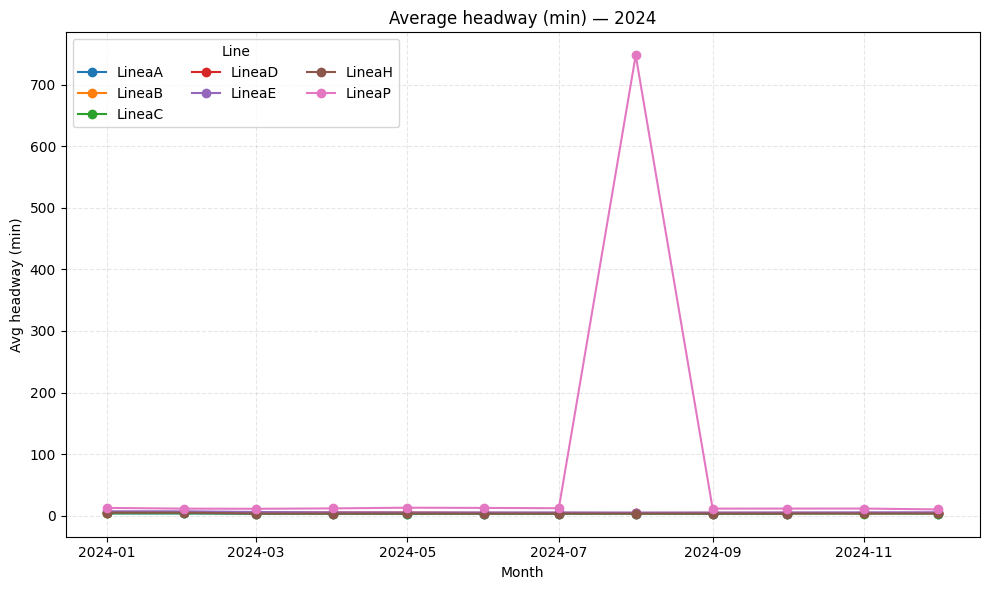

Saved → c:\Users\do_ch\OneDrive\Escritorio\Proyectos\Proyectos GitHub\subte-dashboard\assets\screenshots\week8_headway_trend.png


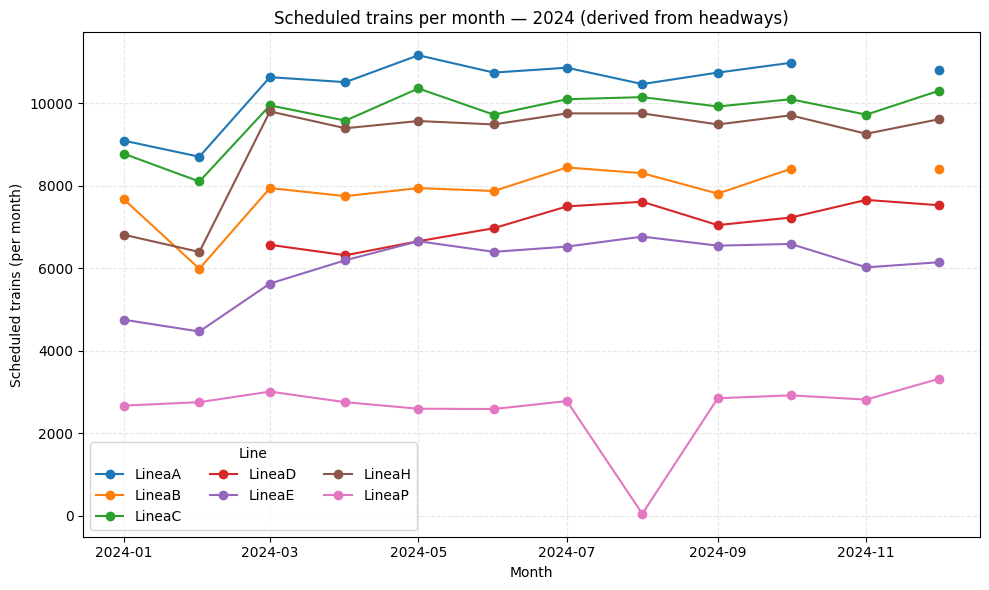

Saved → c:\Users\do_ch\OneDrive\Escritorio\Proyectos\Proyectos GitHub\subte-dashboard\assets\screenshots\week8_scheduled_by_line.png


In [11]:
# --- Block 5: charts (save PNGs) ---

import matplotlib.pyplot as plt

SCREENSHOTS_DIR = ROOT / "assets" / "screenshots"
SCREENSHOTS_DIR.mkdir(parents=True, exist_ok=True)

df_plot = df_sched[df_sched["year"] == 2024].copy()

# 5a) Headway trend (line plot)
plt.figure(figsize=(10,6))
for ln, sub in df_plot.groupby("line", observed=True):
    sub = sub.sort_values("date")
    plt.plot(sub["date"], sub["avg_headway_min"], marker="o", label=ln)
plt.title("Average headway (min) — 2024")
plt.xlabel("Month")
plt.ylabel("Avg headway (min)")
plt.grid(True, linestyle="--", alpha=0.3)
plt.legend(title="Line", ncol=3)
headway_png = SCREENSHOTS_DIR / "week8_headway_trend.png"
plt.tight_layout()
plt.savefig(headway_png, bbox_inches="tight")
plt.show()
print("Saved →", headway_png)

# 5b) Scheduled trains by month & line (line plot)
plt.figure(figsize=(10,6))
for ln, sub in df_plot.groupby("line", observed=True):
    sub = sub.sort_values("date")
    plt.plot(sub["date"], sub["scheduled_trains"], marker="o", label=ln)
plt.title("Scheduled trains per month — 2024 (derived from headways)")
plt.xlabel("Month")
plt.ylabel("Scheduled trains (per month)")
plt.grid(True, linestyle="--", alpha=0.3)
plt.legend(title="Line", ncol=3)
sched_png = SCREENSHOTS_DIR / "week8_scheduled_by_line.png"
plt.tight_layout()
plt.savefig(sched_png, bbox_inches="tight")
plt.show()
print("Saved →", sched_png)


In [12]:
# --- Block 6: optional comparison with official formations_2024 ---

import pandas as pd

FORM_PARQUET = PROCESSED_DIR / "formaciones_2024.parquet"
FORM_CSV     = PROCESSED_DIR / "formaciones_2024.csv"

if FORM_PARQUET.exists() or FORM_CSV.exists():
    if FORM_PARQUET.exists():
        form = pd.read_parquet(FORM_PARQUET)
    else:
        form = pd.read_csv(FORM_CSV)
        form["date"] = pd.to_datetime(form["date"], errors="coerce")

    # monthly official trains
    form["year"] = form["date"].dt.year
    form["month"] = form["date"].dt.month
    form_m = (
        form.groupby(["year","month","line"], observed=True)["trains"]
        .sum().reset_index().rename(columns={"trains":"trains_official"})
    )
    
    # our scheduled (already monthly)
    ours_m = (
        df_sched.groupby(["year","month","line"], observed=True)["scheduled_trains"]
        .sum().reset_index()
    )
    cmp = pd.merge(ours_m, form_m, on=["year","month","line"], how="inner")
    cmp["diff"] = cmp["scheduled_trains"] - cmp["trains_official"]
    cmp["abs_diff"] = cmp["diff"].abs()
    cmp["ym"] = cmp.apply(lambda r: f"{r['year']:04d}-{int(r['month']):02d}", axis=1)

    # Save comparison
    OUT_CMP = PROCESSED_DIR / "week8_scheduled_vs_official.csv"
    cmp.sort_values(["ym","line"]).to_csv(OUT_CMP, index=False)
    print("Comparison saved →", OUT_CMP)

    # Quick diagnostics
    print("\nHead (comparison):")
    display(cmp.head(12))

    mae = float(cmp["abs_diff"].mean()) if len(cmp) else np.nan
    mape = float((cmp["abs_diff"] / cmp["trains_official"].replace(0,np.nan)).mean()) if len(cmp) else np.nan
    print(f"\nMAE (trains/month): {mae:,.2f} | MAPE: {mape:.2%}")
else:
    print("No official formations dataset found (formaciones_2024.(parquet|csv)). Comparison skipped.")


Comparison saved → c:\Users\do_ch\OneDrive\Escritorio\Proyectos\Proyectos GitHub\subte-dashboard\data\processed\week8_scheduled_vs_official.csv

Head (comparison):


,year,month,line,scheduled_trains,trains_official,diff,abs_diff,ym
0,2024,1,LineaA,9090,51972,-42882,42882,2024-01
1,2024,1,LineaB,7667,42821,-35154,35154,2024-01
2,2024,1,LineaC,8772,31863,-23091,23091,2024-01
3,2024,1,LineaD,0,8878,-8878,8878,2024-01
4,2024,1,LineaE,4749,20056,-15307,15307,2024-01
5,2024,1,LineaH,6809,27027,-20218,20218,2024-01
6,2024,1,LineaP,2668,10453,-7785,7785,2024-01
7,2024,2,LineaA,8700,49585,-40885,40885,2024-02
8,2024,2,LineaB,5985,38332,-32347,32347,2024-02
9,2024,2,LineaC,8100,30485,-22385,22385,2024-02



MAE (trains/month): 32,513.39 | MAPE: 80.57%
